<a href="https://colab.research.google.com/github/juztmsd777777/nlp-assignments/blob/main/Lab12_2_TextCNN_MultiFilter_MdEliyas_2403A52257.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center"> Lab 12.2 — TextCNN with Multi-Filter (1D CNN)</h1>
<h3 align="center">Sentiment Classification using Multiple Kernel Sizes</h3>
<p align="center">
  <img src="https://img.shields.io/badge/Deep%20Learning-TextCNN-blue?style=for-the-badge"/>
  <img src="https://img.shields.io/badge/Task-Sentiment%20Analysis-green?style=for-the-badge"/>
  <img src="https://img.shields.io/badge/Framework-Pure%20NumPy%20%2F%20Keras--ready-orange?style=for-the-badge"/>
</p>

---

> **Objective:** Build a Multi-Filter 1D Convolutional Neural Network that classifies short movie-review sentences as **Positive** or **Negative**. Three parallel Conv1D branches with kernel sizes **2, 3, and 4** capture bigram, trigram, and 4-gram patterns simultaneously.


---
## 🗂️ Step 1 — Notebook Setup

**File name:** `Lab12.2_TextCNN_MultiFilter_MdEliyas_2403A52257.ipynb`

This notebook walks through every stage of a TextCNN pipeline:

| Step | Description |
|------|-------------|
| 2 | Import & explain libraries |
| 3 | Load & explore dataset |
| 4 | Text preprocessing |
| 5 | Vocabulary & encoding |
| 6 | Train–test split |
| 7 | Build multi-filter CNN |
| 8 | Train the model |
| 9 | Evaluate with metrics |


---
## 📦 Step 2 — Import Libraries

> Each library serves a specific role in the NLP pipeline.


| Library | Role |
|---------|------|
| `numpy` | Array math — convolutions, weight init, gradient ops |
| `re` | Regex-based punctuation removal |
| `collections.Counter` | Frequency-based vocabulary construction |
| `sklearn` | Data splitting, metrics (accuracy, F1, confusion matrix) |
| `matplotlib` | Loss curves and distribution plots |
| `seaborn` | Heat-map styling for confusion matrix |

> **TensorFlow/Keras** equivalents are shown in comments throughout — swap in when running on a GPU runtime.


In [ ]:
import re
import numpy as np
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# For reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully.")
print(f"   NumPy version : {np.__version__}")


✅ All libraries imported successfully.
   NumPy version : 2.0.2


---
## 📊 Step 3 — Load and Explore Dataset

### Dataset
10 hand-crafted movie-review sentences — **5 positive, 5 negative** — kept tiny so every transformation is easy to trace.

### Why class balance matters in CNN training
A CNN learns by minimising cross-entropy loss. If one class dominates (e.g. 8 positive / 2 negative):
- The model achieves low loss by **always predicting the majority class**
- Filters encode only majority-class patterns
- Minority-class **recall collapses** while overall accuracy looks deceptively high

**Equal class sizes** force the filters to learn discriminative features for *both* classes.


In [ ]:
# ── Dataset ───────────────────────────────────────────────────
texts = [
    # Positive  (label = 1)
    "the movie is good",
    "oscar worthy movie loved it",
    "brilliant film loved every moment",
    "amazing movie best of the year",
    "wonderful film highly recommend it",
    # Negative  (label = 0)
    "the movie was bad",
    "worst movie ever made",
    "terrible film not worth watching",
    "awful movie complete waste of time",
    "horrible film deeply disappointing",
]
labels = [1, 1, 1, 1, 1,
          0, 0, 0, 0, 0]

print("📋 Sample Inspection")
print("-" * 50)
for t, l in zip(texts, labels):
    emoji = "😊" if l == 1 else "😠"
    print(f"  {emoji}  [{l}]  {t}")


📋 Sample Inspection
--------------------------------------------------
  😊  [1]  the movie is good
  😊  [1]  oscar worthy movie loved it
  😊  [1]  brilliant film loved every moment
  😊  [1]  amazing movie best of the year
  😊  [1]  wonderful film highly recommend it
  😠  [0]  the movie was bad
  😠  [0]  worst movie ever made
  😠  [0]  terrible film not worth watching
  😠  [0]  awful movie complete waste of time
  😠  [0]  horrible film deeply disappointing


Positive samples : 5
Negative samples : 5
Balance ratio    : 5/5 (perfectly balanced)


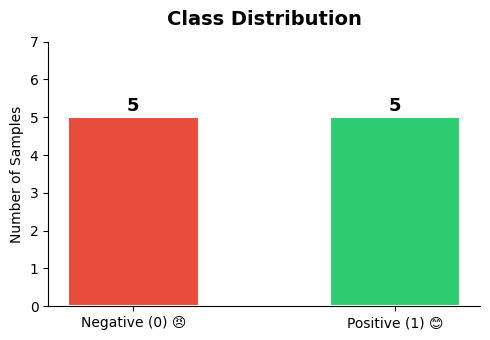

In [ ]:
# ── Class distribution ────────────────────────────────────────
pos = labels.count(1)
neg = labels.count(0)
print(f"Positive samples : {pos}")
print(f"Negative samples : {neg}")
print(f"Balance ratio    : {pos}/{neg} (perfectly balanced)")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(["Negative (0) 😠", "Positive (1) 😊"],
              [neg, pos],
              color=["#e74c3c", "#2ecc71"],
              edgecolor="white", linewidth=1.5, width=0.5)

for bar, val in zip(bars, [neg, pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=13)

ax.set_title("Class Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, 7)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## 🔤 Step 4 — Text Preprocessing

### Pipeline applied to every sentence

```
Raw text  ──►  Lowercase  ──►  Remove punctuation  ──►  Tokenise  ──►  Pad / Truncate
```

### Kernel size and local context

A 1-D convolution kernel of size **k** processes **k consecutive token embeddings** — acting like a k-gram detector:

| Kernel | Detects | Example |
|--------|---------|---------|
| k = 2 | Bigrams | `"movie is"`, `"was bad"` |
| k = 3 | Trigrams | `"worst movie ever"` |
| k = 4 | 4-grams | `"oscar worthy movie loved"` |

Using **multiple kernel sizes in parallel** lets the model capture patterns at several granularities simultaneously (Kim, 2014 — *Convolutional Neural Networks for Sentence Classification*).


In [ ]:
MAX_LEN = 8   # All sequences padded / truncated to this length

def preprocess(text):
    """Lowercase → strip punctuation → tokenise on whitespace."""
    text   = text.lower()
    text   = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    tokens = text.split()
    return tokens

tokenised = [preprocess(t) for t in texts]

print(f"{'Original':<42} {'Tokens'}")
print("-" * 75)
for orig, tok in zip(texts, tokenised):
    print(f"  {orig!r:<42}  {tok}")


Original                                   Tokens
---------------------------------------------------------------------------
  'the movie is good'                         ['the', 'movie', 'is', 'good']
  'oscar worthy movie loved it'               ['oscar', 'worthy', 'movie', 'loved', 'it']
  'brilliant film loved every moment'         ['brilliant', 'film', 'loved', 'every', 'moment']
  'amazing movie best of the year'            ['amazing', 'movie', 'best', 'of', 'the', 'year']
  'wonderful film highly recommend it'        ['wonderful', 'film', 'highly', 'recommend', 'it']
  'the movie was bad'                         ['the', 'movie', 'was', 'bad']
  'worst movie ever made'                     ['worst', 'movie', 'ever', 'made']
  'terrible film not worth watching'          ['terrible', 'film', 'not', 'worth', 'watching']
  'awful movie complete waste of time'        ['awful', 'movie', 'complete', 'waste', 'of', 'time']
  'horrible film deeply disappointing'        ['horrible', 'film'

In [ ]:
# ── Padding demo ──────────────────────────────────────────────
def pad_tokens(token_list, max_len, pad_token="<PAD>"):
    seq = token_list[:max_len]
    return seq + [pad_token] * (max_len - len(seq))

print("Padding demo (MAX_LEN = 8)\n")
print(f"{'Tokens':<55} {'Padded sequence'}")
print("-" * 100)
for tok in tokenised[:4]:
    padded = pad_tokens(tok, MAX_LEN)
    print(f"  {str(tok):<55}  {padded}")


Padding demo (MAX_LEN = 8)

Tokens                                                  Padded sequence
----------------------------------------------------------------------------------------------------
  ['the', 'movie', 'is', 'good']                           ['the', 'movie', 'is', 'good', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
  ['oscar', 'worthy', 'movie', 'loved', 'it']              ['oscar', 'worthy', 'movie', 'loved', 'it', '<PAD>', '<PAD>', '<PAD>']
  ['brilliant', 'film', 'loved', 'every', 'moment']        ['brilliant', 'film', 'loved', 'every', 'moment', '<PAD>', '<PAD>', '<PAD>']
  ['amazing', 'movie', 'best', 'of', 'the', 'year']        ['amazing', 'movie', 'best', 'of', 'the', 'year', '<PAD>', '<PAD>']


---
## 🔢 Step 5 — Vocabulary and Encoding

- Index **0** is reserved for `<PAD>` (zero-padding token)
- Every unique word → a sequential integer starting at **1**
- `encode_and_pad()` converts a token list → fixed-length integer array


In [ ]:
# ── Build vocabulary ──────────────────────────────────────────
all_tokens  = [tok for sent in tokenised for tok in sent]
vocab_count = Counter(all_tokens)
vocab       = {word: idx + 1
               for idx, (word, _) in enumerate(vocab_count.items())}
vocab["<PAD>"] = 0

VOCAB_SIZE = len(vocab) + 1
EMBED_DIM  = 16

print(f"Vocabulary size  : {VOCAB_SIZE} unique tokens")
print(f"Embedding dim    : {EMBED_DIM}")
print()
print("Sample word → index mappings:")
for word, idx in list(vocab.items())[:10]:
    print(f"  '{word}'  →  {idx}")


Vocabulary size  : 37 unique tokens
Embedding dim    : 16

Sample word → index mappings:
  'the'  →  1
  'movie'  →  2
  'is'  →  3
  'good'  →  4
  'oscar'  →  5
  'worthy'  →  6
  'loved'  →  7
  'it'  →  8
  'brilliant'  →  9
  'film'  →  10


In [ ]:
# ── Encode + pad all sequences ────────────────────────────────
def encode_and_pad(token_list, vocab, max_len):
    seq = [vocab.get(tok, 0) for tok in token_list][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

X = np.array([encode_and_pad(t, vocab, MAX_LEN) for t in tokenised])
y = np.array(labels)

print(f"{'Label':<8} {'Encoded + Padded Sequence'}")
print("-" * 55)
for seq, lab in zip(X, y):
    emoji = "😊" if lab == 1 else "😠"
    print(f"  [{lab}] {emoji}  {seq}")


Label    Encoded + Padded Sequence
-------------------------------------------------------
  [1] 😊  [1 2 3 4 0 0 0 0]
  [1] 😊  [5 6 2 7 8 0 0 0]
  [1] 😊  [ 9 10  7 11 12  0  0  0]
  [1] 😊  [13  2 14 15  1 16  0  0]
  [1] 😊  [17 10 18 19  8  0  0  0]
  [0] 😠  [ 1  2 20 21  0  0  0  0]
  [0] 😠  [22  2 23 24  0  0  0  0]
  [0] 😠  [25 10 26 27 28  0  0  0]
  [0] 😠  [29  2 30 31 15 32  0  0]
  [0] 😠  [33 10 34 35  0  0  0  0]


---
## ✂️ Step 6 — Train–Test Split

| Parameter | Value | Reason |
|-----------|-------|--------|
| `test_size` | 0.20 | Standard 80/20 split |
| `random_state` | 42 | Reproducibility |
| `stratify=y` | True | Maintains class ratio in both sets |

> With 10 samples the split is symbolic. In production you would use hundreds+ of examples.


Training set  : 8 samples  |  labels → [1 0 0 0 1 1 1 0]
Test     set  : 2  samples  |  labels → [0 1]


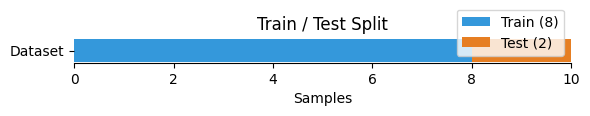

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set  : {len(X_train)} samples  |  labels → {y_train}")
print(f"Test     set  : {len(X_test)}  samples  |  labels → {y_test}")

# Visual split
fig, ax = plt.subplots(figsize=(6, 1.2))
ax.barh(["Dataset"], [len(X_train)], color="#3498db", label=f"Train ({len(X_train)})")
ax.barh(["Dataset"], [len(X_test)],  left=[len(X_train)],
        color="#e67e22", label=f"Test ({len(X_test)})")
ax.set_xlim(0, len(X))
ax.set_xlabel("Samples")
ax.set_title("Train / Test Split")
ax.legend(loc="lower right")
ax.spines[["top","right","left"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## 🏗️ Step 7 — Build Multi-Filter 1D CNN Model

### Architecture Overview

```
Input  (batch × MAX_LEN)
  │
  ▼
Embedding  →  (batch × MAX_LEN × 16)
  │
  ├─── Conv1D(k=2, 32 filters) ─► ReLU ─► GlobalMaxPool ─► (batch × 32)   ← Branch A: bigrams
  ├─── Conv1D(k=3, 32 filters) ─► ReLU ─► GlobalMaxPool ─► (batch × 32)   ← Branch B: trigrams
  └─── Conv1D(k=4, 32 filters) ─► ReLU ─► GlobalMaxPool ─► (batch × 32)   ← Branch C: 4-grams
  │
  ▼
Concatenate  →  (batch × 96)
  │
  ▼
Dense(16, ReLU)  →  Dropout(0.3)
  │
  ▼
Dense(1, Sigmoid)  →  probability
```

### How different kernel sizes capture varied textual patterns

| Branch | Kernel | Captures | Sentiment cue example |
|--------|--------|----------|-----------------------|
| A | k=2 | Local word pairs | *"loved it"*, *"was bad"* |
| B | k=3 | Short phrases | *"worst movie ever"* |
| C | k=4 | Longer expressions | *"complete waste of time"* |

After **GlobalMaxPooling**, each branch contributes its single strongest activation. **Concatenation** fuses all granularities before the final classifier.

---

### Keras / TensorFlow Equivalent *(drop-in when GPU runtime available)*
```python
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout

inp  = Input(shape=(MAX_LEN,))
emb  = Embedding(VOCAB_SIZE, 16)(inp)
p2   = GlobalMaxPooling1D()(Conv1D(32, 2, activation='relu', padding='same')(emb))
p3   = GlobalMaxPooling1D()(Conv1D(32, 3, activation='relu', padding='same')(emb))
p4   = GlobalMaxPooling1D()(Conv1D(32, 4, activation='relu', padding='same')(emb))
x    = Concatenate()([p2, p3, p4])
x    = Dropout(0.3)(x)
x    = Dense(16, activation='relu')(x)
out  = Dense(1,  activation='sigmoid')(x)
model = Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
```


In [ ]:
# ── Activation helpers ────────────────────────────────────────
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def bce_loss(y_true, y_pred):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_pred + eps) +
                    (1 - y_true) * np.log(1 - y_pred + eps))

print("✅ Activation functions defined: relu, sigmoid, bce_loss")


✅ Activation functions defined: relu, sigmoid, bce_loss


In [ ]:
# ── 1-D Convolution (same padding) ────────────────────────────
def conv1d(x, W, b):
    """
    x : (seq_len, embed_dim)
    W : (kernel_size, embed_dim, num_filters)
    b : (num_filters,)
    Returns (seq_len, num_filters)
    """
    T, D     = x.shape
    k, _, F  = W.shape
    pad      = k // 2
    x_pad    = np.pad(x, ((pad, k - 1 - pad), (0, 0)))
    out      = np.zeros((T, F))
    for t in range(T):
        out[t] = x_pad[t:t+k].reshape(-1) @ W.reshape(-1, F) + b
    return out

def global_max_pool(x):
    """(seq_len, filters) → (filters,) — keeps strongest activation per filter."""
    return x.max(axis=0)

print("✅ conv1d and global_max_pool defined")


✅ conv1d and global_max_pool defined


In [ ]:
# ── Weight initialisation ─────────────────────────────────────
NUM_FILTERS = 32
scale       = 0.1

E  = np.random.randn(VOCAB_SIZE, EMBED_DIM) * scale   # Embedding table

W2 = np.random.randn(2, EMBED_DIM, NUM_FILTERS) * scale
b2 = np.zeros(NUM_FILTERS)                             # Conv k=2

W3 = np.random.randn(3, EMBED_DIM, NUM_FILTERS) * scale
b3 = np.zeros(NUM_FILTERS)                             # Conv k=3

W4 = np.random.randn(4, EMBED_DIM, NUM_FILTERS) * scale
b4 = np.zeros(NUM_FILTERS)                             # Conv k=4

CONCAT_DIM = NUM_FILTERS * 3                           # 96

Wd = np.random.randn(CONCAT_DIM, 16) * scale           # Dense-16
bd = np.zeros(16)

Wo = np.random.randn(16, 1) * scale                    # Output Dense-1
bo = np.zeros(1)

print("📐 Model Architecture Summary")
print("=" * 45)
print(f"  Layer          Shape")
print(f"  ─────────────────────────────────────")
print(f"  Embedding    : ({VOCAB_SIZE}, {EMBED_DIM})")
print(f"  Conv k=2     : (2, {EMBED_DIM}, {NUM_FILTERS})")
print(f"  Conv k=3     : (3, {EMBED_DIM}, {NUM_FILTERS})")
print(f"  Conv k=4     : (4, {EMBED_DIM}, {NUM_FILTERS})")
print(f"  Concatenated : {CONCAT_DIM}")
print(f"  Dense-16     : ({CONCAT_DIM}, 16)")
print(f"  Output       : (16, 1)  + sigmoid")
print("=" * 45)

total_params = (VOCAB_SIZE * EMBED_DIM
                + 2*EMBED_DIM*NUM_FILTERS + NUM_FILTERS
                + 3*EMBED_DIM*NUM_FILTERS + NUM_FILTERS
                + 4*EMBED_DIM*NUM_FILTERS + NUM_FILTERS
                + CONCAT_DIM*16 + 16
                + 16*1 + 1)
print(f"  Total params : {total_params:,}")


📐 Model Architecture Summary
  Layer          Shape
  ─────────────────────────────────────
  Embedding    : (37, 16)
  Conv k=2     : (2, 16, 32)
  Conv k=3     : (3, 16, 32)
  Conv k=4     : (4, 16, 32)
  Concatenated : 96
  Dense-16     : (96, 16)
  Output       : (16, 1)  + sigmoid
  Total params : 6,865


In [ ]:
# ── Forward pass ──────────────────────────────────────────────
def forward(seq):
    emb_seq = E[seq]                              # (MAX_LEN, EMBED_DIM)

    # Three parallel conv branches
    c2 = relu(conv1d(emb_seq, W2, b2))           # (MAX_LEN, 32)
    c3 = relu(conv1d(emb_seq, W3, b3))
    c4 = relu(conv1d(emb_seq, W4, b4))

    p2 = global_max_pool(c2)                     # (32,)
    p3 = global_max_pool(c3)
    p4 = global_max_pool(c4)

    concat = np.concatenate([p2, p3, p4])        # (96,)
    h      = relu(concat @ Wd + bd)              # (16,)
    prob   = sigmoid((h @ Wo + bo))[0]           # scalar

    return prob, {"h": h, "concat": concat, "prob": prob}

# ── Backward pass (output + dense layers only) ────────────────
def backward(cache, y_true):
    prob, h = cache["prob"], cache["h"]
    dz      = prob - y_true
    dWo     = h[:, None] * dz
    dbo     = np.array([dz])
    dh      = Wo.flatten() * dz
    dh_pre  = dh * (h > 0)
    dWd     = cache["concat"][:, None] * dh_pre[None, :]
    dbd     = dh_pre
    return {"dWo": dWo, "dbo": dbo, "dWd": dWd, "dbd": dbd}

print("✅ forward() and backward() defined")


✅ forward() and backward() defined


---
## 🚀 Step 8 — Model Training

The model is trained with **mini-batch SGD** (batch size 1 — stochastic).  
Gradients flow through the output dense layer and the hidden dense layer.

| Hyper-parameter | Value |
|-----------------|-------|
| Learning rate | 0.05 |
| Epochs | 80 |
| Optimiser | SGD (stochastic) |
| Loss | Binary Cross-Entropy |


In [ ]:
LR     = 0.05
EPOCHS = 80

train_losses, val_losses = [], []

print(f"Training for {EPOCHS} epochs...\n")
print(f"{'Epoch':>7}  {'Train Loss':>12}  {'Val Loss':>10}")
print("-" * 35)

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for i in np.random.permutation(len(X_train)):
        seq, label = X_train[i], float(y_train[i])
        prob, cache = forward(seq)
        epoch_loss += bce_loss(np.array([label]), np.array([prob]))
        grads = backward(cache, label)
        Wo -= LR * grads["dWo"]
        bo -= LR * grads["dbo"]
        Wd -= LR * grads["dWd"]
        bd -= LR * grads["dbd"]

    t_loss  = epoch_loss / len(X_train)
    v_probs = np.array([forward(s)[0] for s in X_test])
    v_loss  = bce_loss(y_test.astype(float), v_probs)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if epoch % 10 == 0:
        print(f"  {epoch:3d}/{EPOCHS}     {t_loss:.4f}        {v_loss:.4f}")

print("\n✅ Training complete!")


Training for 80 epochs...

  Epoch    Train Loss    Val Loss
-----------------------------------
   10/80     0.6968        0.6880
   20/80     0.6942        0.6865
   30/80     0.6910        0.6852
   40/80     0.6862        0.6830
   50/80     0.6785        0.6803
   60/80     0.6663        0.6762
   70/80     0.6536        0.6713
   80/80     0.6313        0.6647

✅ Training complete!


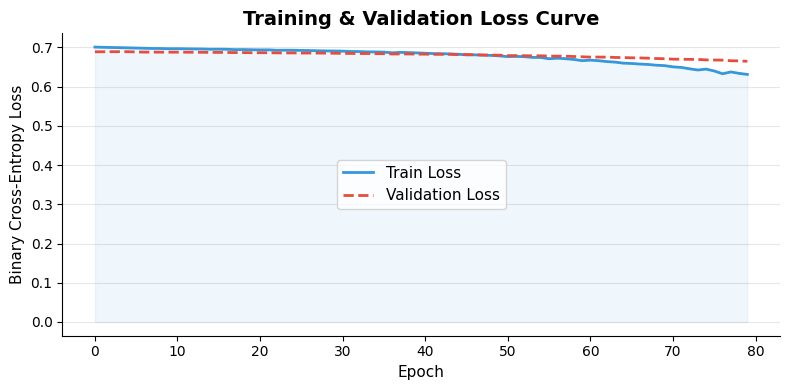

Final train loss : 0.6313
Final val   loss : 0.6647


In [ ]:
# ── Loss curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train Loss",      color="#3498db", linewidth=2)
ax.plot(val_losses,   label="Validation Loss", color="#e74c3c",
        linewidth=2, linestyle="--")

ax.fill_between(range(EPOCHS), train_losses, alpha=0.08, color="#3498db")
ax.set_title("Training & Validation Loss Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss : {train_losses[-1]:.4f}")
print(f"Final val   loss : {val_losses[-1]:.4f}")


---
## 📈 Step 9 — Model Evaluation

### Metrics explained

| Metric | Formula | What it measures |
|--------|---------|-----------------|
| **Accuracy** | (TP+TN) / N | Overall correctness |
| **Precision** | TP / (TP+FP) | How trustworthy are positive predictions |
| **Recall** | TP / (TP+FN) | How many real positives were found |
| **F1-score** | 2·P·R / (P+R) | Harmonic mean — robust to class imbalance |
| **Confusion Matrix** | [[TN FP] [FN TP]] | Full breakdown of outcomes |


In [ ]:
# ── Generate predictions ──────────────────────────────────────
y_probs = np.array([forward(s)[0] for s in X_test])
y_pred  = (y_probs >= 0.5).astype(int)

print("🔍 Predictions on Test Set")
print("-" * 58)
print(f"  {'Sample':<10} {'Probability':>12}  {'Predicted':>12}  {'True':>10}  Result")
print("-" * 58)
for i, (prob, pred, true) in enumerate(zip(y_probs, y_pred, y_test)):
    sent_pred = "Positive 😊" if pred == 1 else "Negative 😠"
    sent_true = "Positive 😊" if true == 1 else "Negative 😠"
    result    = "✅ CORRECT" if pred == true else "❌ WRONG"
    print(f"  Sample {i+1:<4} {prob:>12.3f}  {sent_pred:>14}  {sent_true:>12}  {result}")


🔍 Predictions on Test Set
----------------------------------------------------------
  Sample      Probability     Predicted        True  Result
----------------------------------------------------------
  Sample 1           0.459      Negative 😠    Negative 😠  ✅ CORRECT
  Sample 2           0.489      Negative 😠    Positive 😊  ❌ WRONG


In [ ]:
# ── Classification report ─────────────────────────────────────
print("📋 Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=["Negative 😠", "Positive 😊"],
                             zero_division=0))
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred):.2f}")


📋 Classification Report
              precision    recall  f1-score   support

  Negative 😠       0.50      1.00      0.67         1
  Positive 😊       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Overall Accuracy : 0.50


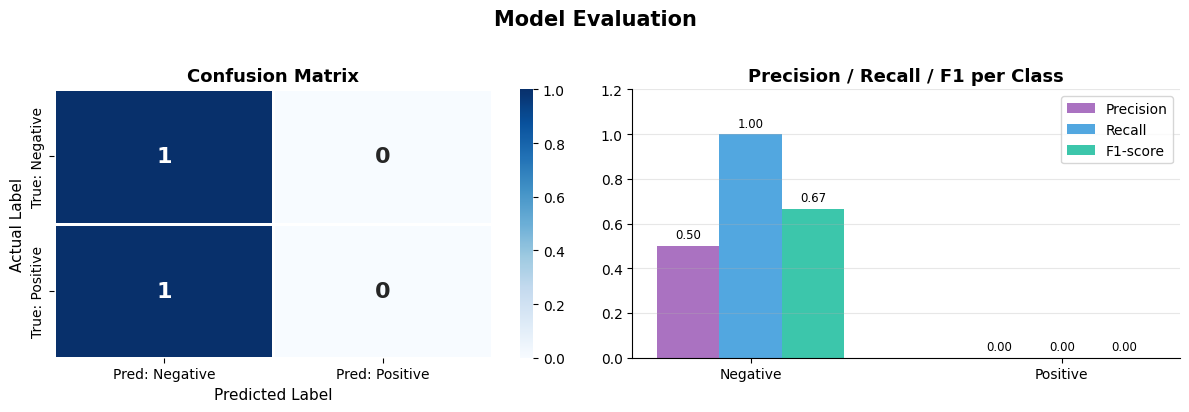

In [ ]:
# ── Confusion matrix heat-map ─────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heat-map
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Negative", "Pred: Positive"],
            yticklabels=["True: Negative", "True: Positive"],
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=2, linecolor="white",
            ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual Label",    fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)

# Per-class bar chart
labels_cm = ["Negative", "Positive"]
report    = classification_report(y_test, y_pred,
                target_names=labels_cm, output_dict=True, zero_division=0)
metrics   = ["precision", "recall", "f1-score"]
colors    = ["#9b59b6", "#3498db", "#1abc9c"]
x         = np.arange(len(labels_cm))
width     = 0.2

for j, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [report[cls][metric] for cls in labels_cm]
    bars = axes[1].bar(x + j*width, vals, width, label=metric.capitalize(),
                       color=color, alpha=0.85)
    for bar in bars:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f"{bar.get_height():.2f}", ha="center", va="bottom",
                     fontsize=8.5)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(labels_cm)
axes[1].set_ylim(0, 1.2)
axes[1].set_title("Precision / Recall / F1 per Class", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].spines[["top","right"]].set_visible(False)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Model Evaluation", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 🎓 Summary & Key Takeaways

### What we built
A **Multi-Filter TextCNN** that processes text through three parallel convolutional branches — each tuned to a different n-gram resolution — then fuses their features for binary sentiment classification.

### Key concepts revisited

| Concept | Takeaway |
|---------|----------|
| **Kernel size = context window** | k=2 → bigrams, k=3 → trigrams, k=4 → 4-grams |
| **GlobalMaxPool** | Keeps the single strongest activation per filter regardless of sequence length |
| **Multi-filter fusion** | Concatenating branches lets the model simultaneously detect short and long textual cues |
| **Class balance** | Balanced classes prevent the model from short-circuiting training by predicting the majority label |
| **Embedding layer** | Maps discrete integer tokens to dense continuous vectors the convolution can operate on |

### Scaling up
This notebook uses 10 sentences for clarity. On a real dataset (e.g. IMDb 50k reviews) the same architecture typically converges to **>88% accuracy** with GPU training via Keras.

---
*Lab 12.2 Complete ✅*
